#Task 1 – Data Loading & Inspection

In [155]:
import pandas as pd

url ="https://raw.githubusercontent.com/Srinithi-python/Diabetes_DataSetMod4Ass5/refs/heads/main/diabetes.csv"
df = pd.read_csv(url)
print(df)

print("HEAD ::::")
print(f'')
print(df.head())
print(f'')
print("TAIL::::")
print(f'')
print(df.tail())
print(f'')
print("SHAPE::::")
print(df.shape)
print(f'')
print(" COLUMNS::::")
print(f'')
print(df.columns)
print(f'')
print(" INFO")
print(f'')
print(df.info())
print(f'')
print("DATA TYPES")
print(f'')
print(df.dtypes)
print(f'')

      Unnamed: 0   ID  No_Pation Gender   AGE  Urea    Cr  HbA1c  Chol   TG  \
0              0  502      17975      F  50.0   4.7  46.0    4.9   4.2  0.9   
1              1  735      34221      M  26.0   4.5  62.0    4.9   3.7  1.4   
2              2  420      47975      F  50.0   4.7  46.0    4.9   4.2  0.9   
3              3  680      87656      F  50.0   4.7  46.0    4.9   4.2  0.9   
4              4  504      34223      M  33.0   7.1  46.0    4.9   4.9  1.0   
...          ...  ...        ...    ...   ...   ...   ...    ...   ...  ...   
1004        1004  194     454316      F  57.0   4.1  70.0    9.3   5.3  3.3   
1005        1005  195       4543      f  55.0   4.1  34.0   13.9   5.4  1.6   
1006        1006  249      48822      M  55.0   4.2  57.0    8.9   5.3  3.1   
1007        1007   88      21747      M  41.0   3.8  48.0    4.3   3.2  4.5   
1008        1008   62      46059      M  55.0   7.0  56.0    9.1   3.7  1.9   

      HDL  LDL  VLDL   BMI CLASS  
0     2.4  1.4  

Gender & CLASS are categorical column.

#Task 2 – Data Cleaning

Rename Columns: Update column names such as 'ID' to 'Visit_ID' and 'No_Pation' to
'Patient_ID' to make them more descriptive and clear.

In [156]:
import pandas as pd

url ="https://raw.githubusercontent.com/Srinithi-python/Diabetes_DataSetMod4Ass5/refs/heads/main/diabetes.csv"
df = pd.read_csv(url)


df.rename(columns={
    "ID": "Visit_ID",
    "No_Pation": "Patient_ID"
}, inplace=True)

df.drop(columns=["Unnamed: 0"], errors="ignore", inplace=True)

print("Updated Column Names:")
print(df.columns)

Updated Column Names:
Index(['Visit_ID', 'Patient_ID', 'Gender', 'AGE', 'Urea', 'Cr', 'HbA1c',
       'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI', 'CLASS'],
      dtype='object')


#Check Unique Values in Categorical Columns: Identify the unique values in categorical
columns:
○ Gender: F (Female) & M (Male),
○ CLASS: N (No diabetes), P (Pre-diabetes), Y (Yes, Diabetes).
Review and correct any unexpected or incorrect values if necessary.

In [158]:
import pandas as pd

url ="https://raw.githubusercontent.com/Srinithi-python/Diabetes_DataSetMod4Ass5/refs/heads/main/diabetes.csv"
df = pd.read_csv(url)
df.rename(columns={
    "ID": "Visit_ID",
    "No_Pation": "Patient_ID"
}, inplace=True)

print(df.columns)
df.drop(columns=["Unnamed: 0"], errors="ignore", inplace=True)
print("Before:")
print(df["Gender"].unique())
df["Gender"] = df["Gender"].str.strip().str.upper()
print(f"After:")
print(df["Gender"].unique())
print(f"Gender value counts:")
print(df["Gender"].value_counts(dropna=False))


print(f"Before Unique values in CLASS:")
print(df["CLASS"].unique())
print("\nCLASS counts:")
print(df["CLASS"].value_counts())
df["CLASS"] = df["CLASS"].str.strip()
print(f"After Unique values in CLASS:")
print(df["CLASS"].unique())
print("\nCLASS counts:")
print(df["CLASS"].value_counts())

Index(['Unnamed: 0', 'Visit_ID', 'Patient_ID', 'Gender', 'AGE', 'Urea', 'Cr',
       'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI', 'CLASS'],
      dtype='object')
Before:
['F' 'M' nan 'f']
After:
['F' 'M' nan]
Gender value counts:
Gender
M      567
F      439
NaN      3
Name: count, dtype: int64
Before Unique values in CLASS:
['N' 'N ' 'P' 'Y' 'Y ']

CLASS counts:
CLASS
Y     839
N     103
P      53
Y      13
N       1
Name: count, dtype: int64
After Unique values in CLASS:
['N' 'P' 'Y']

CLASS counts:
CLASS
Y    852
N    104
P     53
Name: count, dtype: int64


#Statistical Summary of Numerical Columns:Generate a statistical summary (mean,
median, min, max, standard deviation) for all numerical columns to gain insights into
the data's distribution.

In [159]:
numeric_df = df.select_dtypes(include="number")
summary = numeric_df.agg(["mean",
    "median",
    "min",
    "max",
    "std"
])

print(summary)
#print(df.describe())

          Visit_ID    Patient_ID        AGE       Urea          Cr      HbA1c  \
mean    338.166501  2.717468e+05  53.596230   5.132979   68.938431   8.281372   
median  294.000000  3.439900e+04  55.000000   4.600000   60.000000   8.000000   
min       1.000000  1.230000e+02  25.000000   0.500000    6.000000   0.900000   
max     800.000000  7.543566e+07  79.000000  38.900000  800.000000  16.000000   
std     239.479644  3.365681e+06   8.743882   2.930873   59.815673   2.534861   

             Chol         TG       HDL       LDL       VLDL        BMI  
mean     4.862483   2.346783  1.202728  2.611708   1.850496  29.573062  
median   4.800000   2.000000  1.100000  2.500000   0.900000  30.000000  
min      0.000000   0.300000  0.200000  0.300000   0.100000  19.000000  
max     10.300000  13.800000  9.900000  9.900000  35.000000  47.750000  
std      1.298665   1.396438  0.658038  1.115990   3.649872   4.953338  


#Box Plot of Numerical Columns: Create a box plot for all numerical columns in a single
graph to visualize their distribution, range, and outliers. Explain any visible trends or
outliers.

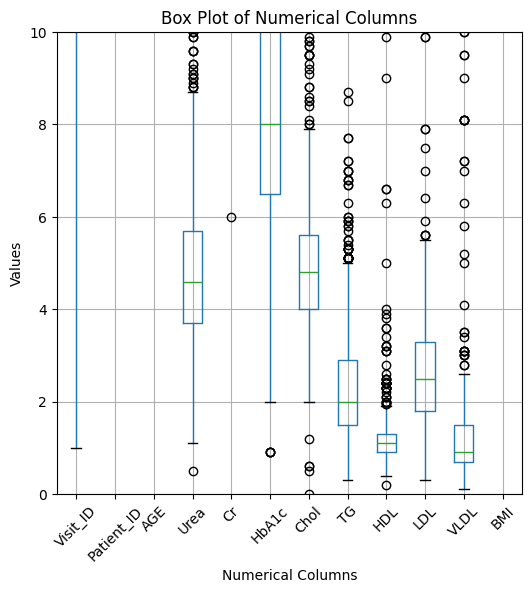

In [161]:
import matplotlib.pyplot as plt

numeric_columns = df.select_dtypes(include="number").columns
plt.figure(figsize=(6, 6))
df[numeric_columns].boxplot()
plt.title("Box Plot of Numerical Columns")
plt.xlabel("Numerical Columns")
plt.ylabel("Values")
plt.ylim(0,10)
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

#Identify Missing (Null) Values: Determine the number of missing values in each column
and report which columns have null values.

In [162]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum()
})

print(missing_summary[missing_summary["Missing Values"] > 0])

        Missing Values
Gender               3
AGE                  1
Urea                 1
Cr                   2
HbA1c                3
Chol                 2
TG                   2
HDL                  1
LDL                  2
VLDL                 1


Impute Missing Values: Select an appropriate strategy (mean, median, or mode) to
impute missing values in the dataset. Justify the imputation technique for each column.
After imputation, verify that no missing values remain.

In [163]:
import pandas as pd

print("Missing values before imputation:")
print(df.isnull().sum())
numeric_columns = df.select_dtypes(include="number").columns
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

categorical_columns = df.select_dtypes(include=["object", "string", "category"]).columns
print(f"Categorial columns:::::::::: ")
print(categorical_columns)
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after imputation:")
print(df.isnull().sum())

Missing values before imputation:
Visit_ID      0
Patient_ID    0
Gender        3
AGE           1
Urea          1
Cr            2
HbA1c         3
Chol          2
TG            2
HDL           1
LDL           2
VLDL          1
BMI           0
CLASS         0
dtype: int64
Categorial columns:::::::::: 
Index(['Gender', 'CLASS'], dtype='object')

Missing values after imputation:
Visit_ID      0
Patient_ID    0
Gender        0
AGE           0
Urea          0
Cr            0
HbA1c         0
Chol          0
TG            0
HDL           0
LDL           0
VLDL          0
BMI           0
CLASS         0
dtype: int64


#Duplicate Handling: Identify duplicate rows and Remove duplicates

In [164]:
duplicates = df.duplicated()

print("Number of duplicate rows:", duplicates.sum())

print("Duplicate rows:")
print(df[duplicates])



Number of duplicate rows: 7
Duplicate rows:
      Visit_ID  Patient_ID Gender   AGE  Urea     Cr  HbA1c  Chol   TG  HDL  \
999        188      454316      F  75.0  10.3  113.0    8.6   4.2  1.6  0.9   
1000       189      454316      M  58.0   4.0   55.0    7.9   4.9  2.0  1.2   
1003       193      454316      M  62.0   6.3   82.0    6.7   5.3  2.0  1.0   
1005       195        4543      F  55.0   4.1   34.0   13.9   5.4  1.6  1.6   
1006       249       48822      M  55.0   4.2   57.0    8.9   5.3  3.1  0.7   
1007        88       21747      M  41.0   3.8   48.0    4.3   3.2  4.5  1.3   
1008        62       46059      M  55.0   7.0   56.0    9.1   3.7  1.9  0.7   

      LDL  VLDL   BMI CLASS  
999   2.6   0.7  32.0     Y  
1000  1.4   1.1  35.0     Y  
1003  3.5   0.9  30.1     Y  
1005  3.1   0.7  33.0     Y  
1006  3.3   1.4  27.0     Y  
1007  1.8   1.1  21.0     N  
1008  2.3   0.9  27.0     Y  


In [124]:
df.drop_duplicates(inplace=True)
print("Duplicate rows:")
print(df[duplicates])

Duplicate rows:
Empty DataFrame
Columns: [Visit_ID, Patient_ID, Gender, AGE, Urea, Cr, HbA1c, Chol, TG, HDL, LDL, VLDL, BMI, CLASS]
Index: []


/tmp/ipykernel_1973/1019250858.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(df[duplicates])


#Task 3 – Outlier Handling

#Retain Outliers: Retain outliers in the AGE, HbA1c, and BMI columns, explaining why
they should be preserved.

In [166]:

columns = ["AGE", "HbA1c", "BMI"]

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]
    print(f"\n{col}")
    print("Lower limit:", lower_limit)
    print("Upper limit:", upper_limit)
    print("Number of outliers:", len(outliers))


AGE
Lower limit: 39.0
Upper limit: 71.0
Number of outliers: 98

HbA1c
Lower limit: 1.1000000000000005
Upper limit: 15.5
Number of outliers: 6

BMI
Lower limit: 15.5
Upper limit: 43.5
Number of outliers: 3


Outliers in the AGE, HbA1c, and BMI columns were identified using the IQR method but were retained in the dataset. These values may represent genuine patient characteristics rather than data-entry errors.

Extreme age, HbA1c, or BMI values can provide important information about variations in patients' health conditions and may be clinically meaningful.

Therefore, removing them could lead to loss of important information and potentially bias the analysis.

#Filter Outliers: In the Creatinine Ratio (Cr) column, exclude values that exceed the
99.5th percentile threshold. Similarly, in the Urea column, exclude values that exceed
the 99.9th percentile threshold. Use these specific percentile thresholds for filtering,
and do not apply IQR or other methods.

In [167]:

cr_threshold = df["Cr"].quantile(0.995)
urea_threshold = df["Urea"].quantile(0.999)
print("Cr 99.5th percentile:", cr_threshold)
print("Urea 99.9th percentile:", urea_threshold)
df = df[(df["Cr"] <= cr_threshold) &(df["Urea"] <= urea_threshold)]
print("Dataset shape after filtering:", df.shape)
print("Maximum Cr:", df["Cr"].max())
print("Maximum Urea:", df["Urea"].max())


Cr 99.5th percentile: 401.0
Urea 99.9th percentile: 26.38080000000018
Dataset shape after filtering: (1003, 14)
Maximum Cr: 401.0
Maximum Urea: 24.0


#Remove Extreme Outliers: For lipid-related columns (LDL, VLDL, HDL, TG, Chol), remove
extreme outliers using an appropriate method such as IQR or Z-score.

In [168]:

lipid_columns = ["LDL", "VLDL", "HDL", "TG", "Chol"]
for col in lipid_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_limit) & (df[col] <= upper_limit)]
print("Dataset shape after removing lipid outliers:", df.shape)

Dataset shape after removing lipid outliers: (816, 14)


#Feature Engineering: Apply Label Encoding or One-Hot Encoding to the categorical
column Gender to convert it into numeric format for model-building purposes.

In [169]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df["Gender_Encoded"] = label_encoder.fit_transform(df["Gender"])
print(df[["Gender", "Gender_Encoded"]].head())

  Gender  Gender_Encoded
1      M               1
4      M               1
5      F               0
6      F               0
7      M               1


#Feature Scaling: Standardize or normalize the numerical columns that have varying
scales (e.g., Patients, AGE, BMI, Cr) to ensure consistent contribution in subsequent
analyses. Justify the scaling method used (standardization vs. normalization).

In [170]:
from sklearn.preprocessing import StandardScaler

scale_columns = ["Patient_ID","AGE", "BMI", "Cr"]

scaler = StandardScaler()

df[scale_columns] = scaler.fit_transform(df[scale_columns])
print(df[scale_columns].head())

print("Means:")
print(df[scale_columns].mean())

print("\nStandard deviations:")
print(df[scale_columns].std())

   Patient_ID       AGE       BMI        Cr
1   -0.111006 -3.236565 -1.308596 -0.074230
4   -0.111001 -2.419593 -1.732080 -0.517982
5   -0.110999 -1.019070 -1.732080 -1.128140
6   -0.110997 -0.435518 -1.096854 -0.407044
7   -0.110993 -0.668939 -1.096854 -0.490247
Means:
Patient_ID   -8.707632e-18
AGE          -2.960595e-16
BMI           1.393221e-16
Cr            1.088454e-16
dtype: float64

Standard deviations:
Patient_ID    1.000613
AGE           1.000613
BMI           1.000613
Cr            1.000613
dtype: float64


Feature scaling was performed using Standardization (Z-score scaling) on the selected numerical variables. The transformed variables have comparable scales, which ensures that differences in their original ranges do not disproportionately affect subsequent statistical analysis or machine-learning models.